# 🔍 키워드 검색 실습

Azure AI Search의 다양한 키워드 검색 기능을 실습합니다.

## 📋 학습 내용

1. **기본 키워드 검색**: 단순 텍스트 검색
2. **필터링 검색**: 카테고리, 가격 등 조건 필터
3. **정렬 검색**: 가격, 점수 기준 정렬
4. **패싯 검색**: 카테고리별, 브랜드별 집계

## 🎯 검색 점수 (BM25)

검색 결과의 `@search.score`는 **BM25 알고리즘**으로 계산된 관련성 점수입니다:
- 높을수록 검색어와 관련성이 높음
- 단어 빈도(TF)와 희귀성(IDF)을 고려
- 문서 길이 정규화 적용

## 1️⃣ 라이브러리 임포트 및 초기화

In [1]:
from azure.search.documents import SearchClient
from azure.core.credentials import AzureKeyCredential
from dotenv import load_dotenv
import os

# 환경 변수 로드
load_dotenv(override=True)
# Azure AI Search 접속 정보
endpoint = os.getenv("SEARCH_ENDPOINT")
key = os.getenv("SEARCH_ADMIN_KEY")
index_name = os.getenv("SEARCH_INDEX_NAME")

# SearchClient 초기화
client = SearchClient(endpoint, index_name, AzureKeyCredential(key))

print("✅ SearchClient 초기화 완료")
print(f"   Endpoint: {endpoint}")
print(f"   Index: {index_name}")

✅ SearchClient 초기화 완료
   Endpoint: https://ai-search-foundry-iq-cj.search.windows.net
   Index: products-index


---

## 2️⃣ 기본 키워드 검색

### 동작 방식
1. 검색어를 형태소 분석 ("여성 가방" → "여성", "가방")
2. 각 단어를 역인덱스에서 검색
3. BM25 점수 계산
4. 점수 높은 순으로 정렬

### 파라미터
- `search_text`: 검색 키워드
- `top`: 상위 N개 결과 반환 (기본값: 50)
- `select`: 반환할 필드 지정

### 검색 설명
- search_text로 전달된 파라미터는 토큰화된 정보 기반으로 다음 컬럼에 자등으로 검색이 됩니다.
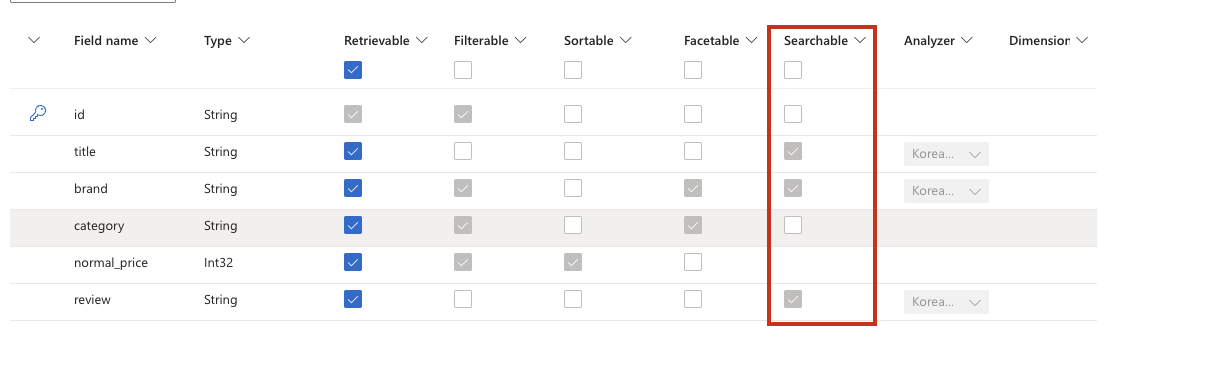

### 토근화란? 
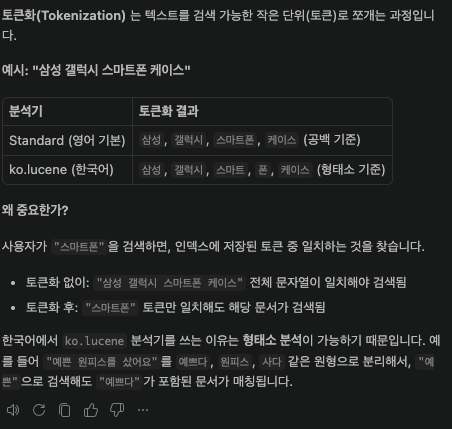

In [2]:
# 검색어 설정
query_text = "여성 가방"

print(f"\n{'='*80}")
print(f"🔍 검색어: '{query_text}'")
print('='*80)

# 검색 실행
results = client.search(
    search_text=query_text,
    top=10,
    select=["title", "brand", "category", "normal_price","review"],
    include_total_count=True
)

print(f"\n📊 총 {results.get_count()}개 결과 (상위 10개 표시)\n")

# 결과 출력
for idx, result in enumerate(results, 1):
    score = result['@search.score']
    print(f"{idx}. [점수: {score:.2f}] {result['title']}")
    print(f"   브랜드: {result['brand']} | 카테고리: {result['category']} | 가격: {result['normal_price']:,}원")
    print(f"   리뷰: {result['review']}")
    print(f"   Orogin: {result}")
    print()


🔍 검색어: '여성 가방'



📊 총 36개 결과 (상위 10개 표시)

1. [점수: 8.00] 노스페이스 NJ2HR41 여성 패커블 LT 자켓  (여성 바람막이 방수자켓)
   브랜드: 노스페이스 | 카테고리: 스포츠/레져 | 가격: 155,800원
   리뷰: 봄철 등산할 때 가볍게 입으려고 구매한 노스페이스 패커블 LT 자켓은 정말 만족스러웠어요. 바람이 많이 부는 날에도 바람막이 역할을 톡톡히 해주고, 방수 기능 덕분에 갑작스러운 소나기에도 큰 걱정 없었어요. 특히 접었을 때 부피가 작아 가방에 쏙 들어가 휴대성이 뛰어났고, 여성용이라 핏도 예쁘게 떨어져서 스타일도 챙길 수 있었답니다. 가격대가 조금 있지만 품질 대비 만족도가 높아 추천할 만해요.
   Orogin: {'normal_price': 155800, 'title': '노스페이스 NJ2HR41 여성 패커블 LT 자켓  (여성 바람막이 방수자켓)', 'brand': '노스페이스', 'category': '스포츠/레져', 'review': '봄철 등산할 때 가볍게 입으려고 구매한 노스페이스 패커블 LT 자켓은 정말 만족스러웠어요. 바람이 많이 부는 날에도 바람막이 역할을 톡톡히 해주고, 방수 기능 덕분에 갑작스러운 소나기에도 큰 걱정 없었어요. 특히 접었을 때 부피가 작아 가방에 쏙 들어가 휴대성이 뛰어났고, 여성용이라 핏도 예쁘게 떨어져서 스타일도 챙길 수 있었답니다. 가격대가 조금 있지만 품질 대비 만족도가 높아 추천할 만해요.', '@search.score': 8.0013685, '@search.reranker_score': None, '@search.highlights': None, '@search.captions': None}

2. [점수: 7.77] 아가방 미키프렌즈손수건세트(10P) 79R0 85102
   브랜드: 아가방플렉스(백화점) | 카테고리: 유아동 | 가격: 22,000원
   리뷰: 아가방 미키프렌즈손수건세트는 디자인이 너무 귀여워서 아이가 좋아해요. 10장이 한 세트로 실용적이고, 부드러운 면 

### 💡 점수 해석

**점수가 높은 이유:**
- "여성"과 "가방" 단어가 모두 포함된 문서
- title 필드에 검색어가 위치한 문서
- 문서 길이가 짧아 키워드 밀도가 높은 문서

**점수가 낮은 이유:**
- 한 단어만 포함 ("여성" 또는 "가방")
- brand나 category 필드에만 포함
- 긴 문서에서 키워드 밀도가 낮음

---

## 3️⃣ 필터링 검색

### OData 필터

Azure AI Search는 **OData 필터 문법**을 사용합니다:

| 연산자 | 사용법 | 예시 |
|--------|--------|------|
| `eq` | 같음 | `category eq '패션잡화'` |
| `ne` | 같지 않음 | `category ne '유아동'` |
| `gt` | 크다 | `normal_price gt 100000` |
| `ge` | 크거나 같다 | `normal_price ge 50000` |
| `lt` | 작다 | `normal_price lt 200000` |
| `le` | 작거나 같다 | `normal_price le 100000` |
| `and` | 그리고 | `category eq '패션잡화' and normal_price le 500000` |
| `or` | 또는 | `category eq '패션잡화' or category eq '스포츠/레져'` |

### 동작 순서
1. **검색**: search_text로 후보 문서 검색
2. **필터**: 후보 중 filter 조건에 맞는 문서만 선택
3. **정렬**: BM25 점수 순으로 정렬
4. **반환**: 상위 N개 반환

In [3]:
# 검색어 및 필터 설정
query_text = "가방"
category_filter = "패션잡화"
max_price = 500000

print(f"\n{'='*80}")
print(f"🔍 검색어: '{query_text}'")
print(f"🎯 카테고리: {category_filter}")
print(f"💰 최대 가격: {max_price:,}원")
print('='*80)

# OData 필터 구성
filter_expression = f"category eq '{category_filter}' and normal_price le {max_price}"

print(f"\n📝 필터 표현식: {filter_expression}\n")

# 검색 실행
results = client.search(
    search_text=query_text,
    filter=filter_expression,
    top=10,
    select=["title", "brand", "category", "normal_price", "review"],
    include_total_count=True
)

print(f"📊 필터 적용 결과: {results.get_count()}개\n")

# 결과 출력
for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")
    print(f"   브랜드: {result['brand']} | 가격: {result['normal_price']:,}원")
    print(f"   리뷰: {result['review']}")
    print()


🔍 검색어: '가방'
🎯 카테고리: 패션잡화
💰 최대 가격: 500,000원

📝 필터 표현식: category eq '패션잡화' and normal_price le 500000

📊 필터 적용 결과: 7개



1. [헤지스핸드백] HISC5E342 베이지 프린트 실크 스카프
   브랜드: 헤지스핸드백 | 가격: 60,480원
   리뷰: 헤지스핸드백의 베이지 프린트 실크 스카프는 고급스러운 소재감이 정말 마음에 들었어요. 실크 특유의 부드러움과 은은한 베이지톤 프린트가 어떤 옷에도 잘 어울려서 데일리로 활용하기 좋습니다. 적당한 크기라 목에 감거나 가방에 매치해도 예쁘고, 봄부터 가을까지 활용도가 높아 만족스럽습니다. 가격 대비 퀄리티가 뛰어나서 선물용으로도 추천하고 싶어요.

2. 앤더슨벨 aaa425u 유니섹스 테크니컬 베를린 스몰 백팩 가방 블랙
   브랜드: 앤더슨벨 | 가격: 205,200원
   리뷰: 앤더슨벨 aaa425u 스몰 백팩은 디자인이 깔끔하면서도 실용적이라 데일리용으로 딱 좋아요. 블랙 색상이 어디에나 잘 어울리고, 공간이 생각보다 넉넉해서 소지품 정리하기 편리했습니다. 특히 테크니컬 원단이라 그런지 가볍고 내구성도 좋아 보여 오래 쓸 수 있을 것 같아요. 어깨끈도 조절 가능해 착용감이 만족스럽고, 활동적인 날에도 부담 없이 들고 다니기 좋아서 구매하길 잘했다는 생각이 듭니다.

3. [헤지스핸드백] HISC5E311 Toile de Jouy 네이비 쁘띠 실크 스카프
   브랜드: 헤지스핸드백 | 가격: 43,680원
   리뷰: 헤지스핸드백의 네이비 쁘띠 실크 스카프는 고급스러운 패턴과 부드러운 감촉이 정말 마음에 듭니다. 적당한 크기로 다양한 스타일링에 활용하기 좋고, 특히 가방 손잡이에 매니쉬하게 연출하니 포인트가 딱 됩니다. 네이비 컬러가 세련돼서 어떤 옷에도 잘 어울리고, 실크라서 피부에 닿는 느낌도 편안해 자주 손이 가는 아이템이에요. 가격 대비 퀄리티 만족스럽고 선물용으로도 추천하고 싶습니다.

4. [아코크] Blooming Hobo Bag_Gray
   브랜드: 아코크(백화점) | 가격: 82,770원
   리뷰: 아코크 블루밍 호보백 그레이 색상 구매했는데 생각보다 수납 공간이 넉넉해서 일상용으로 딱 좋아요. 부드러운 소재라

### 🎨 다양한 필터 예제

In [4]:
# 예제 1: 가격 범위 필터 (10만원 ~ 30만원)
search_text = "신발"

print("\n" + "="*80)
print(f"검색어: {search_text}")
print("예제 1: 가격 범위 필터 (10만원 ~ 30만원)")
print("="*80)

results = client.search(
    search_text=search_text,
    filter="normal_price ge 50000 and normal_price le 300000",
    top=5,
    select=["title", "normal_price"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']} - {result['normal_price']:,}원")


검색어: 신발
예제 1: 가격 범위 필터 (10만원 ~ 30만원)


1. 컨버스 척테일러 1970s 클래식 162058C - 64,600원
2. [윌슨] 드로우스트링 백팩 V1 W253006TBP72 NVY - 151,050원


In [5]:
# 예제 2: 복수 카테고리 필터 (OR 조건)
print("\n" + "="*80)
print("예제 2: 복수 카테고리 필터")
print("="*80)

results = client.search(
    search_text="*",  # 전체 검색
    filter="category eq '패션잡화' or category eq '스포츠/레져'",
    top=5,
    select=["title", "category"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. [{result['category']}] {result['title']}")


예제 2: 복수 카테고리 필터
1. [스포츠/레져] [윌슨] 드로우스트링 백팩 V1 W253006TBP72 NVY
2. [스포츠/레져] [파타고니아코리아] 28818Q7 덕빌 캡 CH
3. [패션잡화] [헬렌카민스키] 헤스터 HESTER
4. [스포츠/레져] BAMKEL 밤켈 모던 22QT 하드쿨러
5. [패션잡화] 폴로 랄프 로렌 여성 폴로 ID 미디엄 레더 숄더백(WAPOBAG02V20040001)


In [6]:
# 예제 3: 특정 브랜드 제외
print("\n" + "="*80)
print("예제 3: 특정 브랜드 제외")
print("="*80)

results = client.search(
    search_text="화장품",
    filter="category eq '이미용' and brand ne '샤넬'",
    top=5,
    select=["title", "brand"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. [{result['brand']}] {result['title']}")


예제 3: 특정 브랜드 제외


1. [명품화장품 펜할리곤스] [펜할리곤스] 로드조지 EDP 75ML
2. [명품화장품 펜할리곤스] [펜할리곤스] 루나 EDT 30ML (+10ML 핸드크림 +1.5ML 샘플 증정)
3. [킬리안-향수] [킬리안] 굿 걸 곤 배드 50ml (리필 가능)
4. [에스티 로더] [에스티 로더]더블웨어 파운데이션 세트(+라뒤레 블렌더 & 마스카라 정품 증정)
5. [산타마리아노벨라] [산타마리아노벨라] 아쿠아 디 로즈 250ml (장미수 토너)  (+미스트 펌프)


---

## 4️⃣ 정렬 검색

### 정렬 옵션

- **`asc`**: 오름차순 (낮은 값 → 높은 값)
- **`desc`**: 내림차순 (높은 값 → 낮은 값)

### 주의사항
- 정렬을 사용하면 **BM25 점수가 무시됨**
- `sortable=True`로 설정된 필드만 정렬 가능
- 여러 필드로 정렬 가능: `["normal_price asc", "title desc"]`

In [7]:
# 검색어 설정
query_text = "스킨케어"
sort_by = "normal_price asc"  # 가격 낮은 순

print(f"\n{'='*80}")
print(f"🔍 검색어: '{query_text}'")
print(f"📊 정렬: {sort_by}")
print('='*80 + "\n")

# 검색 실행
results = client.search(
    search_text=query_text,
    order_by=[sort_by],
    top=10,
    select=["title", "brand", "normal_price"]
)

# 결과 출력
for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")
    print(f"   브랜드: {result['brand']} | 가격: {result['normal_price']:,}원")
    print()


🔍 검색어: '스킨케어'
📊 정렬: normal_price asc



1. 독샤워 허브덴탈오일 DOGS115A0021
   브랜드: 독샤워 | 가격: 21,000원

2. 록시땅 시어 버터 드라이 스킨 핸드크림 150ml
   브랜드: 록시땅 | 가격: 41,000원

3. 정샘물 에센셜 스킨 누더 롱웨어 쿠션(본품+리필)(물 토너15ml + 물크림 라이트 8ml+물결크림5ml)
   브랜드: 정샘물 | 가격: 45,000원

4. [파우치 증정] 선쿠션+클렌징패드 (조카선물 스킨케어선물)
   브랜드: 노베즈 | 가격: 54,000원

5. [메이크업포에버][스벅 1잔] HD SKIN 퍼펙팅 프레스드 파우더 10g (+추가 2종)
   브랜드: 메이크업포에버 | 가격: 62,000원

6. [노베즈][선물포장] 촉촉3종세트 (로션+워시+크림) 선물추천 스킨케어선물 화장품세트
   브랜드: 노베즈 | 가격: 81,000원

7. [디올] 포에버 스킨 글로우 24H 웨어 래디언트 파운데이션
   브랜드: 크리스찬 디올 | 가격: 96,000원

8. [선쿠션증정][보보쇼즈 X 노베즈 콜라보] Fun care essentials 펀케어 에센셜 (로션+올인원워시+샴푸)
   브랜드: 노베즈 | 가격: 99,000원

9. [선쿠션증정][보보쇼즈 X 노베즈 콜라보] For all senses 포 올 센스 (로션+올인원워시+페이스크림)
   브랜드: 노베즈 | 가격: 99,000원

10. [클라랑스]맨 스킨&로션 세트
   브랜드: 클라랑스 | 가격: 118,000원



### 💡 정렬 vs 검색 점수

**정렬 없이 (기본)**
```python
results = client.search(search_text="가방", top=5)
# → BM25 점수 높은 순 (관련성 높은 순)
```

**정렬 사용**
```python
results = client.search(
    search_text="가방",
    order_by=["normal_price asc"],
    top=5
)
# → 가격 낮은 순 (관련성 무시)
```

In [8]:
# 비교: 가격 높은 순 정렬
print("\n" + "="*80)
print("🔍 가격 높은 순 정렬")
print("="*80 + "\n")

results = client.search(
    search_text="가방",
    #order_by=["normal_price desc"],  # 내림차순
    order_by=["normal_price asc"],  # 오름차순
    top=5,
    select=["title", "brand", "normal_price"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")
    print(f"   가격: {result['normal_price']:,}원")
    print()


🔍 가격 높은 순 정렬



1. 록시땅 핸드크림 30ml 컬렉션 (택1)
   가격: 17,000원

2. 아가방 미키프렌즈손수건세트(10P) 79R0 85102
   가격: 22,000원

3. 헤라 [기획]센슈얼 누드 글로스 5g
   가격: 40,000원

4. [헤지스핸드백] HISC5E311 Toile de Jouy 네이비 쁘띠 실크 스카프
   가격: 43,680원

5. 노스페이스 NN2PR54A 남여공용 보레알리스 크로스백 스몰 가방 KR
   가격: 56,050원



---

## 5️⃣ 패싯 검색 (집계)

### 패싯(Facet)이란?

검색 결과를 **카테고리별로 그룹화**하여 개수를 세는 기능입니다.

**활용 사례:**
- 쇼핑몰: "스포츠" 검색 시 → "의류(50개)", "신발(30개)", "가방(20개)"
- 필터 UI: 사용자가 클릭할 수 있는 필터 옵션 제공
- 데이터 분석: 검색 결과의 분포 파악

### 패싯 문법
```python
facets=["category,count:10", "brand,count:5"]
#       필드명    상위N개   필드명   상위N개
```

In [9]:
# 검색어 설정
query_text = "운동"

print(f"\n{'='*80}")
print(f"🔍 검색어: '{query_text}'")
print('='*80)

# 패싯 검색 실행
results = client.search(
    search_text=query_text,
    facets=["category,count:10", "brand,count:10"],
    top=5,
    select=["title", "brand", "category"],
    include_total_count=True
)

print(f"\n📊 총 검색 결과: {results.get_count()}개")

# 패싯 결과 출력
print("\n📊 카테고리별 분포:")
for facet in results.get_facets().get("category", []):
    print(f"  - {facet['value']}: {facet['count']}개")

print("\n📊 브랜드별 분포 (상위 5개):")
for facet in results.get_facets().get("brand", [])[:5]:
    print(f"  - {facet['value']}: {facet['count']}개")

# 검색 결과 (상위 5개)
print("\n🔍 검색 결과 (상위 5개):")
for idx, result in enumerate(results, 1):
    print(f"{idx}. [{result['category']}] {result['title']}")
    print(f"   브랜드: {result['brand']}")
    print()


🔍 검색어: '운동'



📊 총 검색 결과: 17개

📊 카테고리별 분포:
  - 스포츠/레져: 15개
  - 패션잡화: 2개

📊 브랜드별 분포 (상위 5개):
  - 아디다스: 4개
  - 윌슨(백화점): 3개
  - 젝시믹스: 3개
  - 그랜드스테이지: 2개
  - 나이키: 2개

🔍 검색 결과 (상위 5개):


1. [스포츠/레져] [윌슨] 드로우스트링 백팩 V2 W251006TBP13 WHT
   브랜드: 윌슨(백화점)

2. [스포츠/레져] [윌슨] 드로우스트링 백팩 V1 W253006TBP72 NVY
   브랜드: 윌슨(백화점)

3. [스포츠/레져] [윌슨] 리플 스커트 W W253002TSK82 GRN
   브랜드: 윌슨(백화점)

4. [스포츠/레져] [나이키] DF 피트니스 티셔츠 NIKE DX0990-010
   브랜드: 나이키

5. [스포츠/레져] [아디다스코리아공식] JC8149 4.0 3-스트라이프 루즈 크롭 티셔츠 3S LOOSE CROP T 반팔티
   브랜드: 아디다스



### 📊 패싯을 활용한 필터 UI 구현

실제 쇼핑몰에서는 패싯 결과를 사용자 인터페이스로 표시합니다:

```
검색어: "가방"

[ 카테고리 ]
□ 패션잡화 (45개)
□ 스포츠/레져 (12개)
□ 유아동 (8개)

[ 브랜드 ]
□ 롱샴 (15개)
□ 헬렌카민스키 (8개)
□ 폴로 랄프 로렌 (5개)

[ 가격대 ]
□ 10만원 미만 (20개)
□ 10만원 ~ 30만원 (25개)
□ 30만원 이상 (20개)
```

In [10]:
# 전체 데이터의 분포 확인
print("\n" + "="*80)
print("📊 전체 데이터 분포 분석")
print("="*80)

results = client.search(
    search_text="*",  # 와일드카드: 전체 검색
    facets=["category,count:20"],
    top=0,  # 검색 결과는 필요 없음 (집계만)
    include_total_count=True
)

print(f"\n📊 전체 문서 수: {results.get_count()}개\n")
print("카테고리별 분포:")

facets_list = results.get_facets().get("category", [])

for facet in facets_list:
    percentage = (facet['count'] / results.get_count()) * 100
    print(f"  {facet['value']}: {facet['count']}개 ({percentage:.1f}%)")


📊 전체 데이터 분포 분석



📊 전체 문서 수: 247개

카테고리별 분포:
  패션잡화: 47개 (19.0%)
  유아동: 42개 (17.0%)
  이미용: 41개 (16.6%)
  스포츠/레져: 39개 (15.8%)
  주방: 21개 (8.5%)
  문화/취미: 17개 (6.9%)
  패션의류: 13개 (5.3%)
  보석/장신구: 11개 (4.5%)
  인테리어: 9개 (3.6%)
  생활/건강: 4개 (1.6%)
  언더웨어: 3개 (1.2%)


---

## 6️⃣ 리뷰 기반 검색

### 💬 사용후기 검색의 중요성

고객 리뷰는 제품명이나 설명에 없는 **실제 사용 경험**이 담겨 있어 매우 유용한 검색 대상입니다:
- "배송 빠른" → 배송 만족도 높은 제품
- "품질 좋은" → 품질에 대한 긍정적 평가
- "추천합니다" → 전반적 만족도 높은 제품

### 활용 시나리오
- 제품명으로는 찾기 어려운 특정 특징 검색
- 구매 결정에 도움이 되는 실사용 후기 기반 검색
- 긍정/부정 키워드로 제품 필터링

In [11]:
# 예제 1: 리뷰에서 "배송" 키워드 검색
print("\n" + "="*80)
print("예제 1: 리뷰 기반 검색 - '배송 빠른' 제품")
print("="*80 + "\n")

results = client.search(
    search_text="배송 빠르고",
    top=5,
    select=["title", "brand", "category", "review"],
    highlight_fields="review"  # 검색어 하이라이트
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")
    print(f"   브랜드: {result['brand']} | 카테고리: {result['category']}")
    print(f"   리뷰: {result['review'][:150]}...")
    print(f"   Origin: {result}")
    print()


예제 1: 리뷰 기반 검색 - '배송 빠른' 제품



1. [어니스트서울] 14K 랩다이아몬드 5부 4프롱 목걸이
   브랜드: 어니스트서울 | 카테고리: 보석/장신구
   리뷰: 어니스트서울 14K 랩다이아몬드 목걸이를 선물용으로 구매했는데 디자인이 정말 세련되고 고급스러워서 만족스러웠어요. 5부 다이아몬드가 반짝임이 뛰어나고 4프롱 세팅 덕분에 안정감도 있어 매일 착용해도 부담 없었습니다. 가성비도 좋아서 다이아몬드 목걸이를 처음 구매하는 분...
   Origin: {'title': '[어니스트서울] 14K 랩다이아몬드 5부 4프롱 목걸이', 'category': '보석/장신구', 'brand': '어니스트서울', 'review': '어니스트서울 14K 랩다이아몬드 목걸이를 선물용으로 구매했는데 디자인이 정말 세련되고 고급스러워서 만족스러웠어요. 5부 다이아몬드가 반짝임이 뛰어나고 4프롱 세팅 덕분에 안정감도 있어 매일 착용해도 부담 없었습니다. 가성비도 좋아서 다이아몬드 목걸이를 처음 구매하는 분께 추천하고 싶어요. 배송도 빠르고 포장도 깔끔해서 기분 좋게 받았습니다.', '@search.score': 7.817442, '@search.reranker_score': None, '@search.highlights': {'review': ['<em>배송</em>도 <em>빠르</em><em>고</em> 포장도 깔끔해서 기분 좋게 받았습니다.']}, '@search.captions': None}

2. 샤넬 르 르쿠르브 실 드 샤넬
   브랜드: 샤넬 | 카테고리: 이미용
   리뷰: 샤넬 르 르쿠르브 실 드 샤넬을 구매하고 나서 눈가와 입가 주름이 조금씩 완화되는 느낌을 받았어요. 가벼운 텍스처라 끈적임 없이 흡수가 빠르고, 바른 뒤 피부가 매끈해져서 메이크업 전에 사용하기도 좋아요. 가격대가 조금 있지만 고급스러운 향과 효과 덕분에 만족스럽습니다...
   Origin: {'title': '샤넬 르 르쿠르브 실 드 샤넬', 'category': '이미용', 'brand': '샤넬', 'review': '샤넬

In [12]:
# 예제 2: 리뷰에서 "만족" 키워드 검색
print("\n" + "="*80)
print("예제 2: 리뷰 기반 검색 - '만족스럽다' 제품")
print("="*80 + "\n")

results = client.search(
    search_text="만족스럽",
    top=5,
    select=["title", "normal_price", "review"],
    highlight_fields="review",  # 검색어 하이라이트
    include_total_count=True
)

print(f"총 {results.get_count()}개 제품에서 '만족' 키워드 발견\n")

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']} ({result['normal_price']:,}원)")
    print(f"   리뷰: {result['review'][:120]}...")
    print(f"   Origin: {result}")
    
    print()


예제 2: 리뷰 기반 검색 - '만족스럽다' 제품



총 236개 제품에서 '만족' 키워드 발견



1. [Alessi] 알레시 알레산드로M + 안나 와인캡2 블루 기프트 세트 (144,320원)
   리뷰: 알레시 알레산드로M과 안나 와인캡2 블루 세트는 디자인이 정말 세련되어 주방 분위기를 한층 업그레이드해줍니다. 와인캡은 밀폐력이 좋아 와인 신선도를 오래 유지할 수 있었고, 알레산드로M은 그립감이 뛰어나 열기 편리했...
   Origin: {'title': '[Alessi] 알레시 알레산드로M + 안나 와인캡2 블루 기프트 세트', 'review': '알레시 알레산드로M과 안나 와인캡2 블루 세트는 디자인이 정말 세련되어 주방 분위기를 한층 업그레이드해줍니다. 와인캡은 밀폐력이 좋아 와인 신선도를 오래 유지할 수 있었고, 알레산드로M은 그립감이 뛰어나 열기 편리했습니다. 선물용으로도 손색없을 만큼 고급스럽고 실용적인 제품이라 만족스럽습니다.', 'normal_price': 144320, '@search.score': 1.8187301, '@search.reranker_score': None, '@search.highlights': {'review': ['선물용으로도 손색없을 만큼 고급<em>스럽</em>고 실용적인 제품이라 <em>만족</em><em>스</em><em>럽</em>습니다.']}, '@search.captions': None}

2. 폴로 랄프 로렌 남성 풀 그레인 레더 벨트(MAPOBLT0F320300270) (169,000원)
   리뷰: 폴로 랄프 로렌 풀 그레인 레더 벨트를 구매했는데 가죽 질감이 정말 고급스럽고 부드러워서 착용감이 뛰어납니다. 풀 그레인 가죽 특유의 자연스러운 무늬가 멋스럽고 내구성도 좋아 보입니다. 버클도 견고하게 마감되어 있어...
   Origin: {'title': '폴로 랄프 로렌 남성 풀 그레인 레더 벨트(MAPOBLT0F320300270)', 'review': '폴로 랄프 로렌 풀 그레인 레더 벨트를 구매했는데 가죽 질감이 정말 고급스럽고 부드러워서 착용감이 뛰어납니다. 풀 그레인 가죽 특유의 자연스러

In [13]:
# 예제 3: 리뷰 + 카테고리 복합 검색
print("\n" + "="*80)
print("예제 3: 리뷰 + 필터 복합 검색 - '추천' 키워드 + 유아동 제품")
print("="*80 + "\n")

results = client.search(
    search_text="추천",
    filter="category eq '유아동'",
    top=5,
    select=["title", "brand", "category", "normal_price", "review"],
    highlight_fields="review",  # 검색어 하이라이트
    include_total_count=True
)

print(f"유아동 카테고리에서 '추천' 키워드가 있는 제품: {results.get_count()}개\n")

for idx, result in enumerate(results, 1):
    score = result['@search.score']
    print(f"{idx}. [점수: {score:.2f}] {result['title']}")
    print(f"   가격: {result['normal_price']:,}원")
    print(f"   리뷰: {result['review'][:100]}...")
    print()


예제 3: 리뷰 + 필터 복합 검색 - '추천' 키워드 + 유아동 제품



유아동 카테고리에서 '추천' 키워드가 있는 제품: 24개



1. [점수: 2.67] [노베즈][선물포장] 촉촉3종세트 (로션+워시+크림) 선물추천 스킨케어선물 화장품세트
   가격: 81,000원
   리뷰: 아이 피부가 예민해서 순한 제품을 찾다가 노베즈 촉촉3종세트를 구매했어요. 로션과 크림 모두 끈적임 없이 산뜻하게 발리면서도 보습력이 뛰어나서 아침저녁으로 발라주니 피부가 훨씬 촉...

2. [점수: 2.31] 선물추천 [밍크뮤HP]26년말띠선물 (CR)코니밍크애착인형 양말SET(35W70-BHB-01/35A70-011-03)
   가격: 75,200원
   리뷰: 26년 말띠 선물로 밍크뮤 코니밍크 애착인형과 양말 세트를 구매했는데 정말 만족스럽습니다. 인형이 부드럽고 포근해서 아기가 바로 안고 자는 모습이 너무 귀여웠어요. 양말도 퀄리티가...

3. [점수: 1.33] 블루독베이비[hu] PK)블루독뱀부여아손수건SET 43170-006-03 손수건/타올/수건/10장/신생아/출산용품/선물
   가격: 22,190원
   리뷰: 신생아 손수건으로 구매했는데 부드러운 대나무 섬유라 그런지 피부에 자극 없이 정말 좋아요. 10장이 한 세트라 자주 세탁해도 넉넉하고 크기도 적당해서 아기 얼굴 닦거나 입 주변 정...

4. [점수: 1.33] [레고공식] 듀플로 10444 창의적인 정원과 꽃들
   가격: 26,700원
   리뷰: 아이와 함께 놀기 좋은 듀플로 세트입니다. 크고 부드러운 블록이라 아이가 쉽게 조립할 수 있었고, 다양한 꽃과 나무 조각 덕분에 창의력을 발휘하며 정원을 꾸미는 놀이가 재미있었어요...

5. [점수: 1.18] [압소바] 출산선물 티노딸랑이세트 (선물포장) (ATA367P1)
   가격: 40,000원
   리뷰: 친구 아기 출산선물로 압소바 티노딸랑이세트를 구매했어요. 부드러운 소재라 아기 피부에 자극 없고, 딸랑이 소리도 은은해서 너무 마음에 들었습니다. 선물포장도 깔끔하게 되어 있어 바...



### 💡 리뷰 검색 활용 팁

**효과적인 리뷰 검색 키워드:**
- **배송/서비스**: "배송 빠른", "포장 깔끔", "친절"
- **품질**: "품질 좋은", "튼튼", "내구성"
- **만족도**: "만족", "추천", "재구매"
- **가성비**: "가격 대비", "합리적", "저렴"
- **사용감**: "편한", "부드러운", "가벼운"

**비즈니스 활용:**
- 고객 만족도 높은 제품 자동 추천
- 리뷰 기반 제품 큐레이션
- 긍정/부정 키워드 분석으로 제품 개선
- VOC(고객의 소리) 분석

---

## 7️⃣ 고급 검색 기법

### 불린 연산자 사용

In [14]:
# AND 연산자: 두 단어 모두 포함
print("\n" + "="*80)
print("예제 1: AND 연산자 (노스페이스 AND 자켓)")
print("="*80 + "\n")

results = client.search(
    search_text="노스페이스 AND 자켓",
    top=5,
    select=["title", "brand"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")


예제 1: AND 연산자 (노스페이스 AND 자켓)



1. 노스페이스 NJ3LR05 남성 아이스 페이스 자켓 (여름 경량 바람막이 자켓)
2. 노스페이스 NJ2HR11 남성 패커블 LT 자켓 (남성 방수 바람막이 자켓)
3. 노스페이스 NJ2HR41 여성 패커블 LT 자켓  (여성 바람막이 방수자켓)
4. 노스페이스 NE3HR55 여성 모자 우먼즈 와이드 햇
5. 노스페이스 NN2PR54A 남여공용 보레알리스 크로스백 스몰 가방 KR


In [15]:
# OR 연산자: 둘 중 하나라도 포함
print("\n" + "="*80)
print("예제 2: OR 연산자 (신발 OR 운동화)")
print("="*80 + "\n")

results = client.search(
    search_text="신발 OR 운동화",
    top=5,
    select=["title"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")


예제 2: OR 연산자 (신발 OR 운동화)



1. [윌슨] 드로우스트링 백팩 V2 W251006TBP13 WHT
2. [윌슨] 드로우스트링 백팩 V1 W253006TBP72 NVY
3. 컨버스 척테일러 올스타 클래식 블랙 M9166C
4. 컨버스 척테일러 올스타 무브 화이트 570257C
5. 컨버스 척테일러 1970s 클래식 162058C


In [16]:
# NOT 연산자: 특정 단어 제외
print("\n" + "="*80)
print("예제 3: NOT 연산자 (가방 NOT 백팩)")
print("="*80 + "\n")

results = client.search(
    search_text="가방 NOT 백팩",
    top=5,
    select=["title"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")


예제 3: NOT 연산자 (가방 NOT 백팩)



1. 디스커버리 25N 신상품 등산배낭 DXBK5025N 에어 스플리트 백팩 17L 경량가방
2. 아가방 미키프렌즈손수건세트(10P) 79R0 85102
3. [윌슨] 드로우스트링 백팩 V1 W253006TBP72 NVY
4. 앤더슨벨 aaa425u 유니섹스 테크니컬 베를린 스몰 백팩 가방 블랙
5. [파타고니아코리아] 47928Q7 가방 리퓨지오 데이팩 백팩 30L Refugio Daypack 30L 15인치 노트북 PG


### 구문 검색 (Phrase Search)

In [17]:
# 따옴표로 감싸면 정확한 구문으로 검색
print("\n" + "="*80)
print("예제 4: 구문 검색 (\"출산 선물\")")
print("="*80 + "\n")

results = client.search(
    search_text='"출산 선물"',  # 따옴표로 감싸기
    top=5,
    select=["title"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")


예제 4: 구문 검색 ("출산 선물")



1. [M밍크뮤M7]35970BHD02 드림루루딸랑이세트/유아용품/출산준비/임신/출산/백일/조카선물


### 와일드카드 검색

# * : 0개 이상의 문자
# ? : 정확히 1개의 문자
print("\n" + "="*80)
print("예제 5: 와일드카드 검색 (노트*)")
print("="*80 + "\n")

results = client.search(
    search_text="노트*",  # 노트북, 노트, 노트패드 등
    top=5,
    select=["title"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")

### 🔧 Query Type: 검색어 해석 방식

`query_type`은 검색어를 **어떤 파서(Parser)로 해석할지** 결정하는 파라미터입니다.

| query_type | 설명 | 지원 문법 |
|------------|------|-----------|
| `simple` (기본값) | 단순 쿼리 파서 | `+`, `-`, `\|`, `*`, `""`, `()`, AND/OR/NOT |
| `full` | **Full Lucene** 파서 | simple의 모든 것 + **필드 지정**, 부스팅, 근접검색, 정규식 |
| `semantic` | 시맨틱 검색 파서 | AI 기반 의미 재순위화 (06-re_ranking에서 다룸) |

#### 지금까지의 예제는 모두 `simple` (기본값)

AND, OR, NOT, 와일드카드(`*`), 구문검색(`""`)은 `simple`에서도 지원됩니다.
그래서 지금까지 `query_type`을 명시하지 않아도 동작했습니다.

#### `full`에서만 가능한 것들

```python
# 1. 필드 지정 검색: 특정 필드에서만 검색
"title:가방"              # title 필드에서 "가방" 검색
"review:배송"             # review 필드에서 "배송" 검색

# 2. 부스팅: 특정 필드에 가중치 부여
"title:가방^3"            # title 매칭에 3배 가중치

# 3. 근접 검색: 두 단어가 N단어 이내에 등장
'"출산 선물"~5'           # "출산"과 "선물"이 5단어 이내

# 4. 복합: 여러 필드 조합
"title:자켓 AND review:따뜻"  # 제목에 "자켓" + 리뷰에 "따뜻"
```

In [18]:
# 예제 6: 필드 지정 검색 (Full Lucene)
# title 필드에서만 "가방" 검색
print("\n" + "="*80)
print("예제 6: 필드 지정 검색 - title 필드에서 '가방'")
print("query_type='full' 사용")
print("="*80 + "\n")

results = client.search(
    search_text="title:가방",
    query_type="full",  # Full Lucene 파서 활성화
    top=5,
    select=["title", "brand", "category"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")
    print(f"   카테고리: {result['category']} | 브랜드: {result['brand']}")
    print()


예제 6: 필드 지정 검색 - title 필드에서 '가방'
query_type='full' 사용



1. 디스커버리 25N 신상품 DXCR5145N 커브 패디드 드로스트링 퍼커링 백 M 여행가방 보조가방
   카테고리: 스포츠/레져 | 브랜드: 디스커버리

2. 앤더슨벨 aaa425u 유니섹스 테크니컬 베를린 스몰 백팩 가방 블랙
   카테고리: 패션잡화 | 브랜드: 앤더슨벨

3. 디스커버리 25N 신상품 가방 DXSG5105N 리프레임 티어 드롭 라지 슬링백 여행가방 보조가방
   카테고리: 스포츠/레져 | 브랜드: 디스커버리

4. 아가방 미키프렌즈손수건세트(10P) 79R0 85102
   카테고리: 유아동 | 브랜드: 아가방플렉스(백화점)

5. 디스커버리 25N 신상품 DXCR5115N 리프레임 호보 크로스백 여행가방 보조가방
   카테고리: 스포츠/레져 | 브랜드: 디스커버리



In [19]:
# 예제 7: review 필드에서만 검색
print("\n" + "="*80)
print("예제 7: 필드 지정 검색 - review 필드에서 '배송'")
print("="*80 + "\n")

results = client.search(
    search_text="review:배송",
    query_type="full",
    top=5,
    select=["title", "review"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")
    print(f"   리뷰: {result['review'][:100]}...")
    print()


예제 7: 필드 지정 검색 - review 필드에서 '배송'



1. [어니스트서울] 14K 랩다이아몬드 5부 4프롱 목걸이
   리뷰: 어니스트서울 14K 랩다이아몬드 목걸이를 선물용으로 구매했는데 디자인이 정말 세련되고 고급스러워서 만족스러웠어요. 5부 다이아몬드가 반짝임이 뛰어나고 4프롱 세팅 덕분에 안정감도 ...



In [20]:
# 예제 8: 부스팅 - title 매칭에 3배 가중치
# title에서 "가방"이 매칭되면 점수를 3배로 올림
print("\n" + "="*80)
print("예제 8: 부스팅 - title:가방^3 (title 매칭에 3배 가중치)")
print("="*80 + "\n")

results = client.search(
    search_text="title:가방^3",
    query_type="full",
    top=5,
    select=["title", "brand", "category"]
)

for idx, result in enumerate(results, 1):
    score = result['@search.score']
    print(f"{idx}. [점수: {score:.2f}] {result['title']}")
    print(f"   카테고리: {result['category']} | 브랜드: {result['brand']}")
    print()


예제 8: 부스팅 - title:가방^3 (title 매칭에 3배 가중치)



1. [점수: 8.56] 디스커버리 25N 신상품 DXCR5145N 커브 패디드 드로스트링 퍼커링 백 M 여행가방 보조가방
   카테고리: 스포츠/레져 | 브랜드: 디스커버리

2. [점수: 7.94] 앤더슨벨 aaa425u 유니섹스 테크니컬 베를린 스몰 백팩 가방 블랙
   카테고리: 패션잡화 | 브랜드: 앤더슨벨

3. [점수: 7.85] 디스커버리 25N 신상품 가방 DXSG5105N 리프레임 티어 드롭 라지 슬링백 여행가방 보조가방
   카테고리: 스포츠/레져 | 브랜드: 디스커버리

4. [점수: 7.30] 아가방 미키프렌즈손수건세트(10P) 79R0 85102
   카테고리: 유아동 | 브랜드: 아가방플렉스(백화점)

5. [점수: 5.72] 디스커버리 25N 신상품 DXCR5115N 리프레임 호보 크로스백 여행가방 보조가방
   카테고리: 스포츠/레져 | 브랜드: 디스커버리



In [21]:
# 예제 9: 근접 검색 - "출산"과 "선물"이 5단어 이내에 등장하는 문서
print("\n" + "="*80)
print('예제 9: 근접 검색 - "출산 선물"~5')
print("="*80 + "\n")

results = client.search(
    search_text='"출산 선물"~5',
    query_type="full",
    top=5,
    select=["title", "review"]
)

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")
    print(f"   리뷰: {result['review'][:120]}...")
    print()


예제 9: 근접 검색 - "출산 선물"~5



1. [M밍크뮤M7]35970BHD02 드림루루딸랑이세트/유아용품/출산준비/임신/출산/백일/조카선물
   리뷰: 조카 출산 선물로 밍크뮤 드림루루 딸랑이세트를 구매했어요. 부드러운 소재와 안전한 디자인 덕분에 아기가 안심하고 가지고 놀더라고요. 크기도 적당해서 아기 손에 딱 맞고, 소리도 자극적이지 않아 너무 좋아요. 패키지도...

2. [압소바] 출산선물 티노딸랑이세트 (선물포장) (ATA367P1)
   리뷰: 친구 아기 출산선물로 압소바 티노딸랑이세트를 구매했어요. 부드러운 소재라 아기 피부에 자극 없고, 딸랑이 소리도 은은해서 너무 마음에 들었습니다. 선물포장도 깔끔하게 되어 있어 바로 전달하기 좋았고, 디자인도 귀여워...

3. (에뜨와) (말띠해출산선물)헨리우주복V블로니양말(2종세트) (07S71750H) (유아/출산/백일/돌선물/조카선물)
   리뷰: 조카 돌선물로 헨리우주복과 블로니양말 세트를 구매했어요. 우주복은 부드러운 소재라 아기 피부에 자극 없고 착용감도 좋아서 조카가 편안해했답니다. 블로니양말도 디자인이 귀엽고 발을 잘 감싸줘서 따뜻하게 잘 신기고 있어...

4. (에뜨와) (07P083101) (임신출산백일선물)코니딸랑이세트(6종) (유아/출산/백일/돌선물/조카선물)
   리뷰: 조카 백일선물로 에뜨와 코니딸랑이세트 6종을 구매했어요. 부드러운 소재에 색감도 은은해서 아기가 자극받지 않고 좋아하더라고요. 크기도 적당해서 아기 손에 쏙 들어가고, 다양한 딸랑이 소리가 난다는 점이 특히 마음에 ...

5. [압소바1] 곰고무연사목욕타올+손수건+인형세트 MIAZA-10911 [임신/출산선물]
   리뷰: 신생아 목욕용으로 압소바 곰고무연사목욕타올 세트를 구입했는데 부드러운 소재 덕분에 아기의 피부에 자극 없이 잘 사용하고 있어요. 주머니가 있어 손수건과 귀여운 곰 인형도 함께 있어 목욕 시간이 더 즐거워졌습니다. 세...



In [22]:
# 예제 10: 복합 필드 조합 - title에 "자켓" AND review에 "따뜻"
print("\n" + "="*80)
print("예제 10: 복합 필드 검색 - title:자켓 AND review:따뜻")
print("="*80 + "\n")

results = client.search(
    search_text="title:자켓 AND review:여름",
    query_type="full",
    top=5,
    select=["title", "review"]
)

found = False
for idx, result in enumerate(results, 1):
    found = True
    score = result['@search.score']
    print(f"{idx}. [점수: {score:.2f}] {result['title']}")
    print(f"   리뷰: {result['review'][:120]}...")
    print()

if not found:
    print("(결과 없음 - 두 조건을 동시에 만족하는 문서가 없습니다)")


예제 10: 복합 필드 검색 - title:자켓 AND review:따뜻



1. [점수: 5.26] 노스페이스 NJ3LR05 남성 아이스 페이스 자켓 (여름 경량 바람막이 자켓)
   리뷰: 노스페이스 아이스 페이스 자켓은 여름철 가볍게 입기 딱 좋은 바람막이예요. 소재가 얇고 통기성이 좋아서 땀 차는 느낌 없이 시원하게 착용할 수 있었습니다. 특히 바람을 잘 막아줘서 아침저녁 선선할 때도 부담 없이 입...



---

## 8️⃣ 실전 예제: 복합 검색

실제 쇼핑몰에서 사용되는 복합 검색 시나리오를 구현합니다.

In [23]:
# 시나리오: "여성 여름 의류" 검색, 패션 카테고리, 20만원 이하, 가격 낮은 순
print("\n" + "="*80)
print("🛍️ 실전 예제: 여성 여름 의류 (패션 카테고리, 20만원 이하, 저가순)")
print("="*80)

results = client.search(
    search_text="여성 여름",
    filter="category eq '패션의류' and normal_price le 200000",
    order_by=["normal_price asc"],
    top=10,
    select=["title", "brand", "category", "normal_price"],
    include_total_count=True
)

print(f"\n📊 총 {results.get_count()}개 결과\n")

for idx, result in enumerate(results, 1):
    print(f"{idx}. {result['title']}")
    print(f"   브랜드: {result['brand']} | 가격: {result['normal_price']:,}원")
    print()


🛍️ 실전 예제: 여성 여름 의류 (패션 카테고리, 20만원 이하, 저가순)



📊 총 4개 결과



1. 라코스테우먼 25SS 여성 스트라이프 긴팔 티셔츠 TF922E-55G HBP
   브랜드: 라코스테 우먼 | 가격: 93,870원

2. 라코스테우먼 25SS 여성 베이직 린넨셔츠 CF905E-55G AFS
   브랜드: 라코스테 우먼 | 가격: 137,970원

3. [타미힐피거 여성] T22F6KTO041WT1 린넨 케이블 크루넥 스웨터
   브랜드: 타미힐피거 | 가격: 197,100원

4. [타미힐피거여성] 코튼 케이블 카라 스웨터 2색상 T22F6KTO003WT2
   브랜드: 타미힐피거 | 가격: 197,100원



---

## ✅ 학습 완료!

축하합니다! 키워드 검색의 핵심 기능을 모두 학습했습니다.

### 📚 학습한 내용

1. ✅ **기본 키워드 검색**: BM25 점수 기반 관련성 검색
2. ✅ **필터링 검색**: OData 필터로 조건 검색
3. ✅ **정렬 검색**: 가격, 날짜 등 기준 정렬
4. ✅ **패싯 검색**: 카테고리별 집계 및 필터 UI
5. ✅ **불린 연산자**: AND, OR, NOT 활용
6. ✅ **구문/와일드카드 검색**: 고급 쿼리 기법
7. ✅ **복합 검색**: 실전 시나리오 구현

### 🚀 다음 단계

이제 더 고급 검색 기능을 학습할 준비가 되었습니다:

1. **벡터 검색 (Vector Search)** - 의미 기반 검색
2. **하이브리드 검색 (Hybrid Search)** - 키워드 + 벡터 결합
3. **시맨틱 검색 (Semantic Search)** - AI 재순위화

### 📖 참고 자료

- [Azure AI Search 쿼리 문법](https://learn.microsoft.com/azure/search/query-lucene-syntax)
- [OData 필터 참조](https://learn.microsoft.com/azure/search/search-query-odata-filter)
- [BM25 알고리즘](https://learn.microsoft.com/azure/search/index-similarity-and-scoring)

---

## 🧭 다음 단계

| ⬅️ 이전 | 🏠 목차 | ➡️ 다음 |
|:---------|:-------:|--------:|
| [Lab 02-2: 데이터 업로드](02-upload_data.ipynb) | [워크숍 홈](../README.md) | [Lab 03-1: 벡터 인덱스 업데이트](../03-vector_search/01-update_index.ipynb) |